In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import h5py, os

import tensorflow as tf
tf.config.experimental.set_memory_growth(tf.config.list_physical_devices(device_type="GPU")[0], True)

import numpy as np
import healpy as hp
import matplotlib.pyplot as plt

from tqdm import tqdm

# from msfm.grid_pipeline import GridPipeline
# from msfm.utils import logger, input_output, files, scales, power_spectra, parameters

# from deep_lss.models.grid_model import GridLossModel
# from deep_lss.utils import optimization, configuration
# from deep_lss.nets.mlp import MultiLayerPerceptron

from msfm.utils import files
from deep_lss.utils import configuration
from msi.utils import dataset, preprocessing, input_output

In [3]:
msfm_conf = files.load_config("/global/homes/a/athomsen/multiprobe-simulation-forward-model/configs/v10/linear_bias.yaml")
base_dir = "/pscratch/sd/a/athomsen/v11desy3/v10/linear_bias"
mocks = ["Buzzard", "Cardinal"]

# msfm_conf = files.load_config("/global/homes/a/athomsen/multiprobe-simulation-forward-model/configs/v10/linear_bias_octant.yaml")
# base_dir = "/pscratch/sd/a/athomsen/v11desy3/v10/linear_bias_octant"
# mocks = ["MICE"]

# for the white noise level
dlss_conf = configuration.load_deep_lss_config("/global/u2/a/athomsen/y3-deep-lss/configs/v10/combined/dlss_config.yaml")

out_dir = "/pscratch/sd/a/athomsen/run_files/v10"

# with_lensing = True
# with_clustering = False
# params = ["Om", "s8", "w0", "Aia", "n_Aia"]

with_lensing = False
with_clustering = True
params = ["Om", "s8", "w0", "bg", "n_bg"]

# with_lensing = True
# with_clustering = True
# params = ["Om", "s8", "w0", "Aia", "n_Aia", "bg", "n_bg"]

# with_cross_z = False
with_cross_z = True

24-09-17 00:09:47 configuratio INF   Loaded the config 


24-09-17 00:09:47 preprocessin INF   Reading the smoothing scale from the DLSS configuration file 
24-09-17 00:09:47 preprocessin INF   Loading the pre-binned Cls 
24-09-17 00:09:47 input_output INF   Array shapes: 
24-09-17 00:09:47 input_output INF   fiducial/i_example = (35920,) 
24-09-17 00:09:47 input_output INF   fiducial/i_noise   = (35920,) 
24-09-17 00:09:48 input_output INF   fiducial/cls/binned = (35920, 32, 36) 
24-09-17 00:09:48 input_output INF   fiducial/cls/bin_edges = (33, 36) 
24-09-17 00:09:48 input_output INF   grid/cosmo         = (2500, 400, 12) 
24-09-17 00:09:48 input_output INF   grid/i_example     = (2500, 400) 
24-09-17 00:09:48 input_output INF   grid/i_noise       = (2500, 400) 
24-09-17 00:09:48 input_output INF   grid/i_sobol       = (2500, 400) 
24-09-17 00:09:50 input_output INF   grid/cls/binned    = (2500, 400, 32, 36) 
24-09-17 00:09:50 input_output INF   grid/cls/bin_edges = (2500, 33, 36) 
24-09-17 00:09:50 input_output INF   Done loading the summa

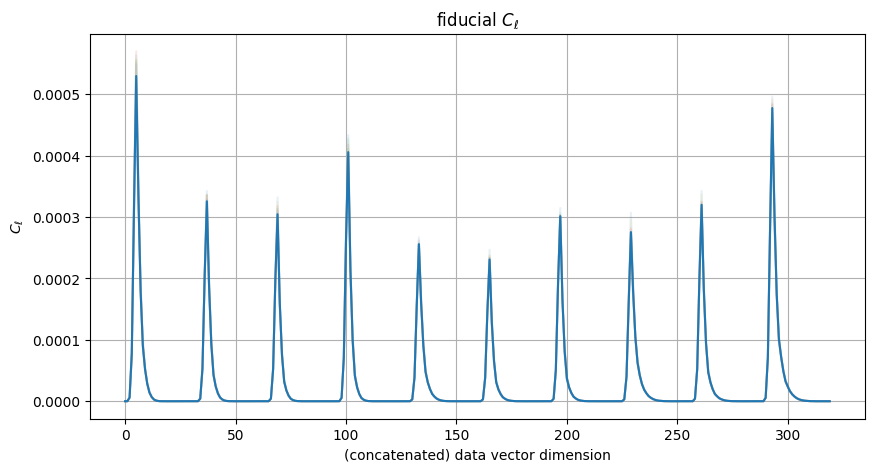

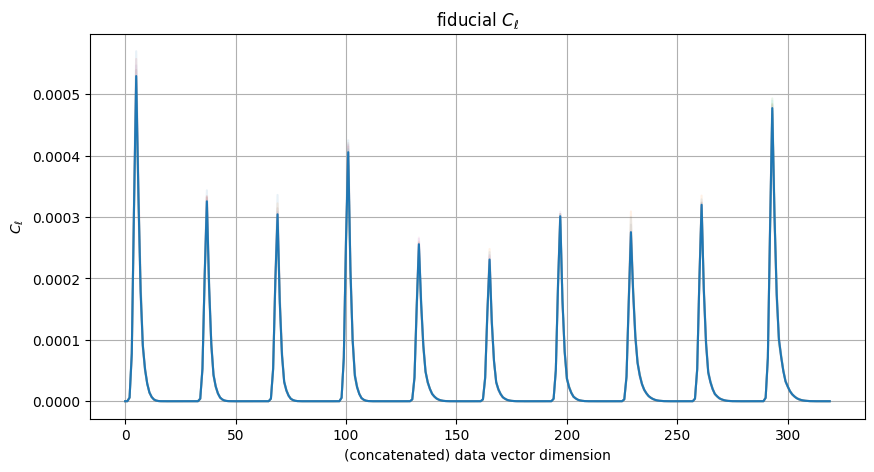

In [4]:
cl_dset_noisy, _, out_dict_noisy = dataset.get_binned_power_spectra_dset(
    base_dir, 
    # configuration
    msfm_conf=msfm_conf,
    dlss_conf=dlss_conf,
    params=params,
    # selection
    with_lensing=with_lensing,
    with_clustering=with_clustering,
    with_cross_z=with_cross_z,
    with_gaussian_noise=True,
    apply_log=False,
)

cl_dset_signal, _, out_dict_signal = dataset.get_binned_power_spectra_dset(
    base_dir, 
    # configuration
    msfm_conf=msfm_conf,
    dlss_conf=dlss_conf,
    params=params,
    # selection
    with_lensing=with_lensing,
    with_clustering=with_clustering,
    with_cross_z=with_cross_z,
    with_gaussian_noise=False,
    apply_log=False,
)

In [5]:
# i = 0

# fig, ax = plt.subplots(figsize=(20,5))

# ax.plot(out_dict_noisy["fidu/cls"][i], label="noisy")
# ax.plot(out_dict_signal["fidu/cls"][i], label="noiseless")

# # ax.set(ylim=(-30,-6))
# ax.legend()
# ax.set(scal

[None]

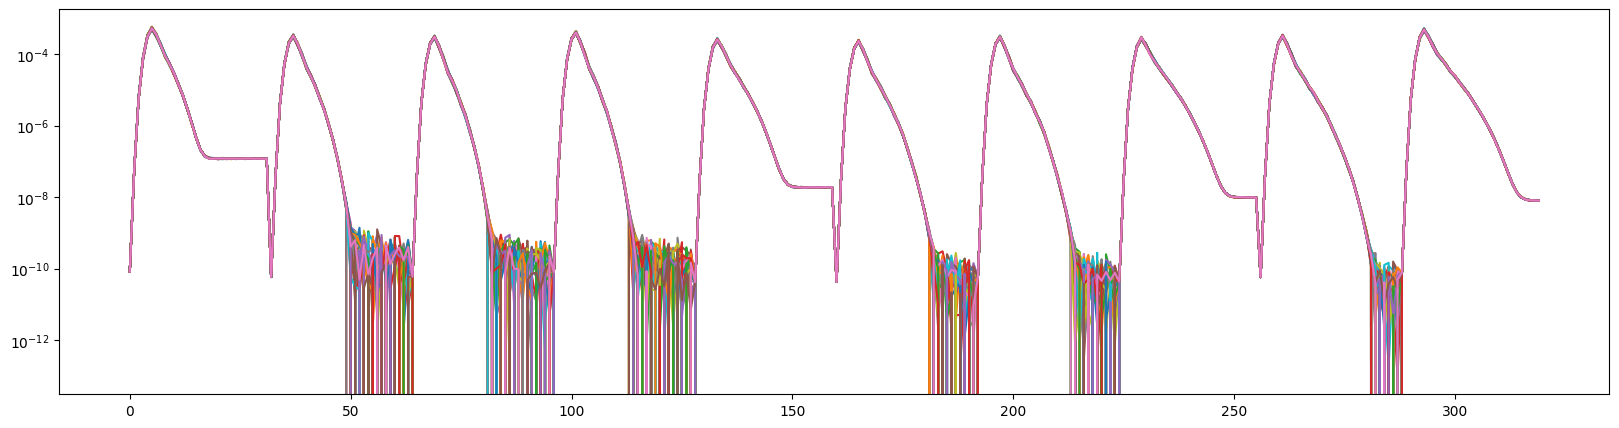

In [6]:
fig, ax = plt.subplots(figsize=(20,5))

for i in range(0, 1000, 13):
    # print(i)
    ax.plot(out_dict_noisy["fidu/cls"][i], label="noisy")#, color="blue", alpha=0.5)
#     ax.plot(out_dict_signal["fidu/cls"][i], label="noiseless", color="red", alpha=0.5)
    
#     print(i, out_dict_noisy["fidu/cls"][i][:10])

# ax.set(ylim=(-30,-6))
# ax.legend()
ax.set(yscale="log")

[None]

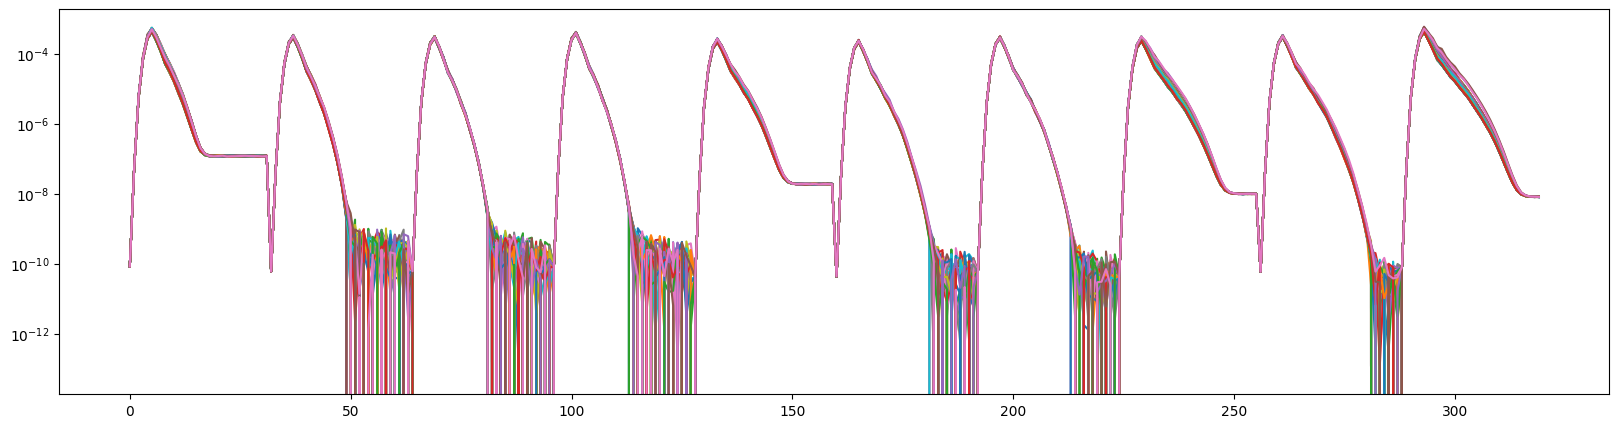

In [7]:
fig, ax = plt.subplots(figsize=(20,5))

for i in range(0, 1000, 13):
    ax.plot(out_dict_noisy["grid/cls/train"][i], label="noisy")#, color="blue", alpha=0.5)
#     ax.plot(out_dict_signal["fidu/cls"][i], label="noiseless", color="red", alpha=0.5)
    
#     print(i, out_dict_noisy["fidu/cls"][i][:10])

# ax.set(ylim=(-30,-6))
# ax.legend()
ax.set(yscale="log")

100%|██████████| 3/3 [00:04<00:00,  1.56s/it]


[Text(0.5, 0, '$\\ell$'), Text(0, 0.5, '$C_\\ell$'), (-30.0, -6.0)]

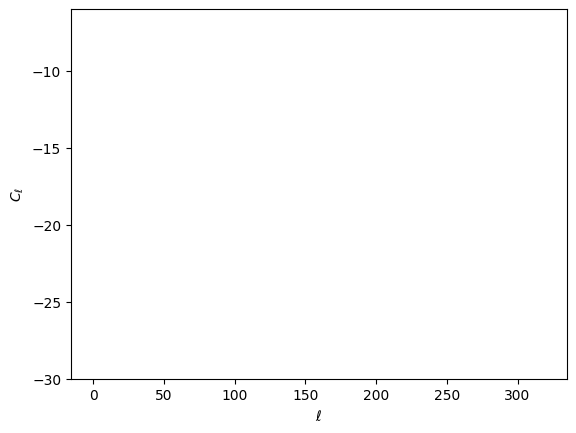

In [8]:
fig, ax = plt.subplots()

examples = 3
for i, (cl_batch, cosmo_batch) in tqdm(enumerate(cl_dset_noisy.take(examples)), total=examples):
    ax.plot(cl_batch[0])

ax.set(xlabel=r"$\ell$", ylabel=r"$C_\ell$", ylim=(-30,-6))

100%|██████████| 3/3 [00:04<00:00,  1.53s/it]


[Text(0.5, 0, '$\\ell$'), Text(0, 0.5, '$C_\\ell$')]

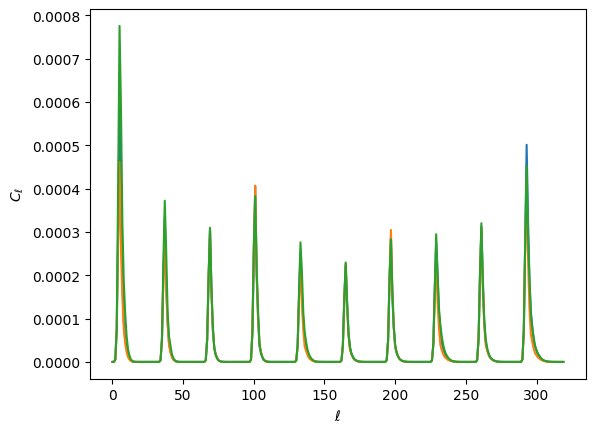

In [9]:
fig, ax = plt.subplots()

examples = 3
for i, (cl_batch, cosmo_batch) in tqdm(enumerate(cl_dset_signal.take(examples)), total=examples):
    ax.plot(cl_batch[0])

ax.set(xlabel=r"$\ell$", ylabel=r"$C_\ell$")

# preprocessing

(100000, 32, 36)


[None]

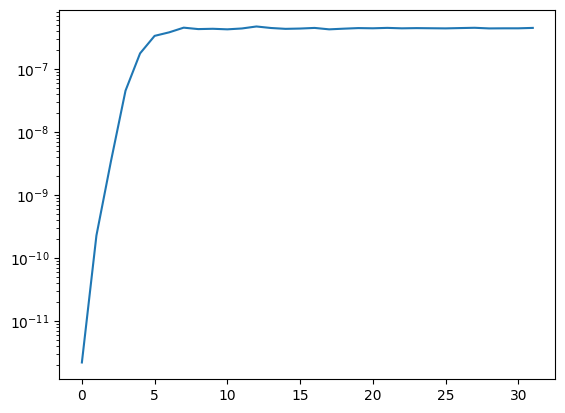

In [10]:
noise_cls_raw = input_output.load_cl_white_noise(base_dir)
print(noise_cls_raw.shape)

fig, ax = plt.subplots()
ax.plot(noise_cls_raw[0,:,0])
ax.set(yscale="log")

In [11]:
# noise_cls_raw = input_output.load_cl_white_noise(base_dir)

# fig, ax = plt.subplots()

# n_examples = 10
# indices = np.random.randint(0, noise_cls_raw.shape[0], n_examples)

# ax.plot(noise_cls_raw[indices,0].T)
# ax.set(xscale="linear", yscale="log")

# print(noise_cls_raw[0,:,0])

In [12]:
fidu_cls, grid_cls, noise_cls, grid_cosmos, grid_i_sobols, file_dict, scaler, pca = (
        preprocessing.get_reshaped_human_summaries(
            base_dir,
            "cls",
            file_label=None,
            # configuration
            msfm_conf=msfm_conf,
            dlss_conf=dlss_conf,
            params=params,
            concat_example_dim=False,
            do_plot=False,
            # selection
            with_lensing=True,
            with_clustering=False,
            with_cross_z=False,
            with_cross_probe=False,
            # power spectra: scales
            from_raw_cls=False,
            # unlike the standardization, the logarithm is not linear and has to be applied as log(signal + noise), not
            # log(signal) + log(noise)
            apply_log=False,
            standardize=False,
            pca_components=None,
        )
    )

24-09-17 00:10:51 preprocessin INF   Reading the smoothing scale from the DLSS configuration file 
24-09-17 00:10:51 preprocessin INF   Loading the pre-binned Cls 
24-09-17 00:10:51 input_output INF   Array shapes: 
24-09-17 00:10:51 input_output INF   fiducial/i_example = (35920,) 
24-09-17 00:10:51 input_output INF   fiducial/i_noise   = (35920,) 
24-09-17 00:10:52 input_output INF   fiducial/cls/binned = (35920, 32, 36) 
24-09-17 00:10:52 input_output INF   fiducial/cls/bin_edges = (33, 36) 
24-09-17 00:10:52 input_output INF   grid/cosmo         = (2500, 400, 12) 
24-09-17 00:10:52 input_output INF   grid/i_example     = (2500, 400) 
24-09-17 00:10:52 input_output INF   grid/i_noise       = (2500, 400) 
24-09-17 00:10:52 input_output INF   grid/i_sobol       = (2500, 400) 
24-09-17 00:10:54 input_output INF   grid/cls/binned    = (2500, 400, 32, 36) 
24-09-17 00:10:54 input_output INF   grid/cls/bin_edges = (2500, 33, 36) 
24-09-17 00:10:54 input_output INF   Done loading the summa

In [13]:
noise_cls[0,:32]

array([1.1893606e-19, 1.2301349e-17, 1.8630778e-16, 2.4442576e-15,
       9.5416322e-15, 1.8097703e-14, 2.0585772e-14, 2.4428493e-14,
       2.3176370e-14, 2.3446704e-14, 2.2976702e-14, 2.3710731e-14,
       2.5504677e-14, 2.4127593e-14, 2.3385587e-14, 2.3645641e-14,
       2.4193224e-14, 2.2966407e-14, 2.3535083e-14, 2.4049481e-14,
       2.3866232e-14, 2.4231495e-14, 2.3835934e-14, 2.4026332e-14,
       2.3903588e-14, 2.3784453e-14, 2.4063708e-14, 2.4316315e-14,
       2.3759699e-14, 2.3844635e-14, 2.3846552e-14, 2.4211930e-14],
      dtype=float32)

[None]

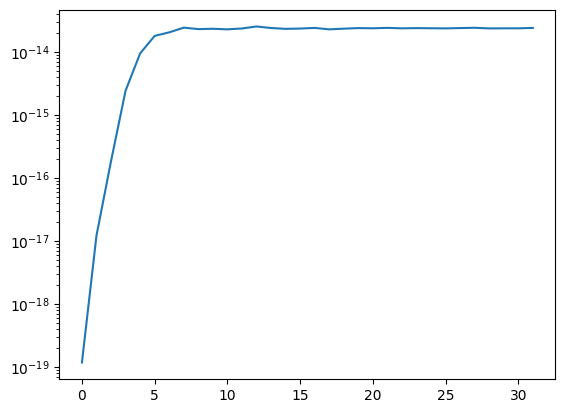

In [14]:
fig, ax = plt.subplots()

ax.plot(noise_cls[0,:32])
ax.set(yscale="log")

[None, None]

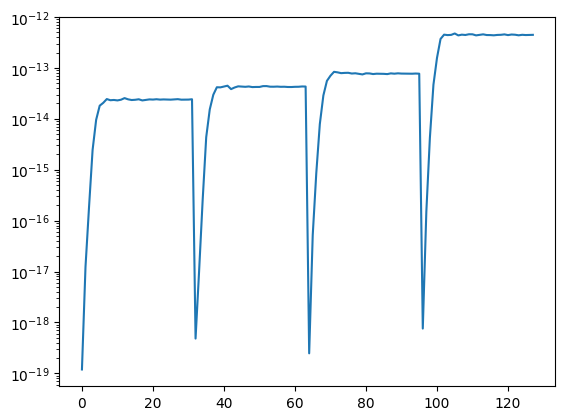

In [15]:
fig, ax = plt.subplots()

n_examples = 10
indices = np.random.randint(0, noise_cls.shape[0], n_examples)

ax.plot(noise_cls[0])

# ax.plot(noise_cls[indices].T)
ax.set(xscale="linear", yscale="log")

[None, None]

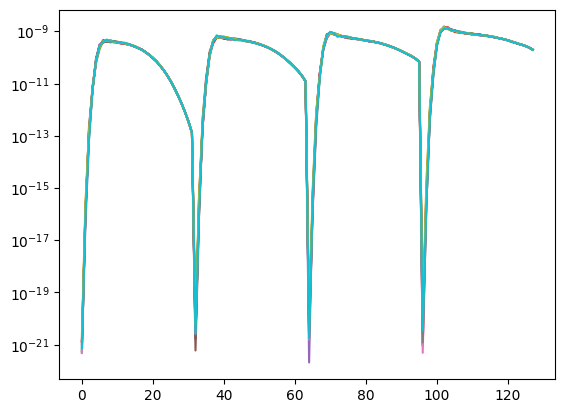

In [16]:
fig, ax = plt.subplots()

n_examples = 10
indices = np.random.randint(0, fidu_cls.shape[0], n_examples)

ax.plot(fidu_cls[indices].T)
ax.set(xscale="linear", yscale="log")

[None, None]

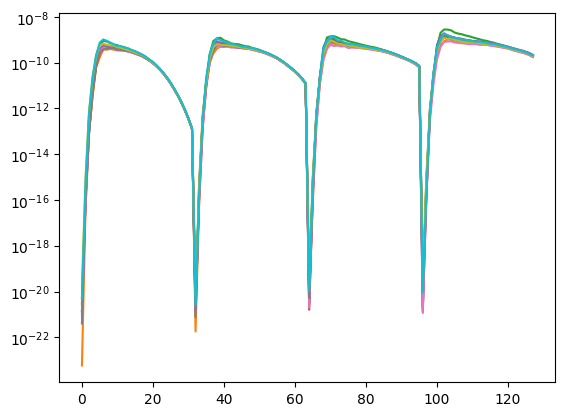

In [17]:
fig, ax = plt.subplots()

n_examples = 10
indices = np.random.randint(0, grid_cls.shape[0], n_examples)

ax.plot(grid_cls[indices,0].T)
ax.set(xscale="linear", yscale="log")